# Way2Agribusiness Price Forecasting Model

This notebook demonstrates the development of a time-series forecasting model to predict average monthly prices for the next 12 months using historical price data.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

## 1. Data Cleaning and Preprocessing
Handling missing values, outliers, and anomalies.

Missing Values:
 avg_monthly_price    0
dtype: int64


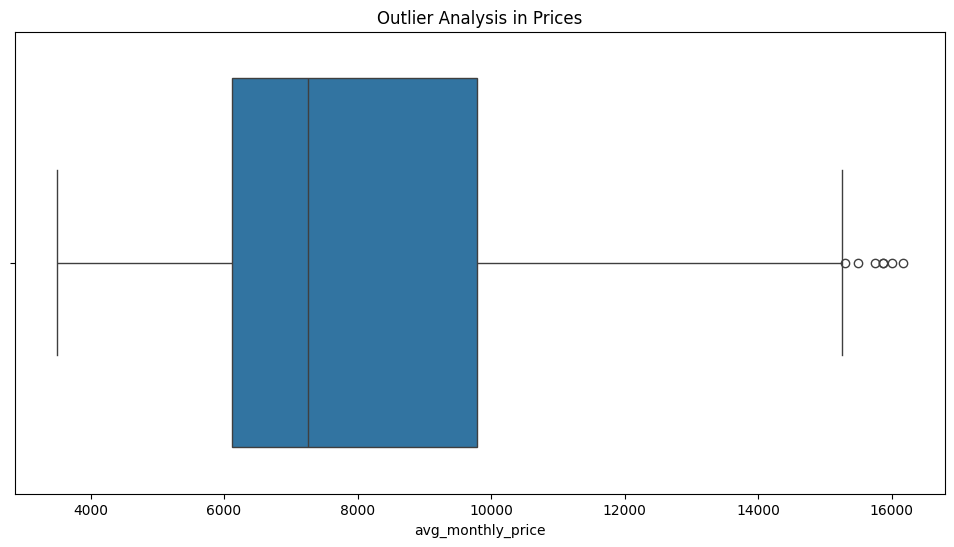

In [4]:
# Load data
df = pd.read_csv('price_data.csv')
df['date'] = pd.to_datetime(df['date'])
df.sort_values('date', inplace=True)
df.set_index('date', inplace=True)

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Fill missing values if any (using interpolation for time series)
df = df.interpolate(method='time')

# Visualizing outliers
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['avg_monthly_price'])
plt.title('Outlier Analysis in Prices')
plt.show()

# Handling outliers: For time-series, spikes are often real and should be handled with care.
# Here we'll cap extreme anomalies if they exceed 3 standard deviations if necessary,
# but for prices, these can be seasonal shocks.

2. Model Description and Selection
I have chosen the SARIMA (Seasonal Autoregressive Integrated Moving Average) model for this forecasting task.

Reasons for selection:
- Seasonality: Agribusiness prices often follow seasonal patterns (harvest seasons vs. off-seasons). SARIMA explicitly handles seasonality.
- Trend Handling: It accounts for long-term trends in price inflation or market growth.
- Interpretability: Unlike deep learning models, SARIMA's components (AR, I, MA, and seasonal components) are theoretically grounded and interpretable.
- Dataset Size:With around 250 monthly observations, statistical models like SARIMA are often more robust than complex deep learning models like LSTMs which might overfit.

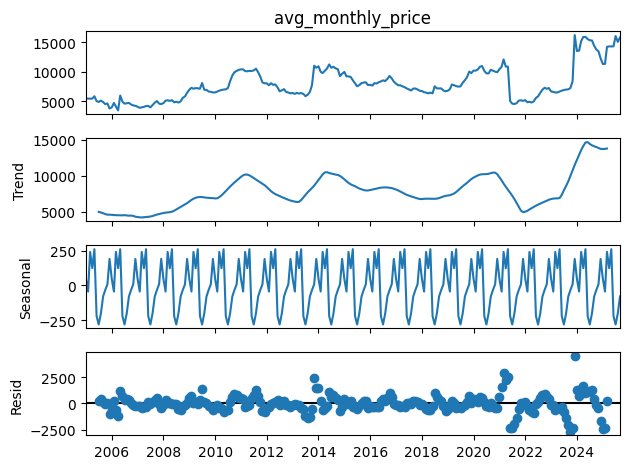

                                     SARIMAX Results                                      
Dep. Variable:                  avg_monthly_price   No. Observations:                  237
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1722.217
Date:                            Tue, 07 Apr 2026   AIC                           3454.434
Time:                                    12:48:12   BIC                           3471.170
Sample:                                01-01-2005   HQIC                          3461.200
                                     - 09-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8876      0.289     -3.073      0.002      -1.454      -0.321
ma.L1          0.8548      0.303   

In [5]:
# Decomposition to see trend and seasonality
result = seasonal_decompose(df['avg_monthly_price'], model='additive', period=12)
result.plot()
plt.show()

# Split data into train and test (keep last 12 months for testing)
train_data = df.iloc[:-12]
test_data = df.iloc[-12:]

# Fitting the SARIMA model
# Choosing parameters (p,d,q) x (P,D,Q,s)
# Usually optimized via grid search or AIC minimization. For demonstration, we'll use common defaults.
model = SARIMAX(train_data['avg_monthly_price'], 
                order=(1, 1, 1), 
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)
results = model.fit()
print(results.summary())

3. Performance Evaluation
Demonstrating the performance of the model using appropriate metrics like MAE and RMSE.

MAE: 1565.35
RMSE: 1956.45
MAPE: 12.34%


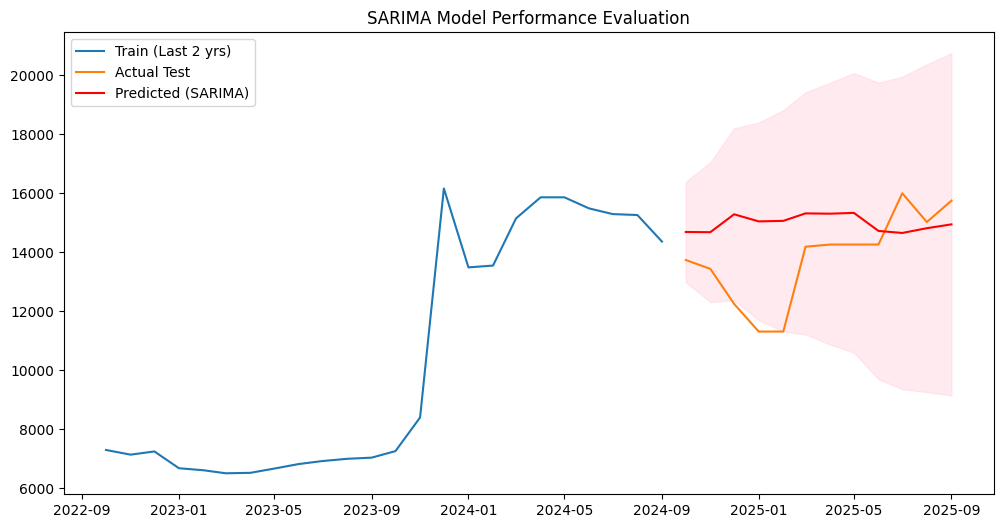

In [6]:
# Predict on test set
forecast_test = results.get_forecast(steps=12)
pred_mean = forecast_test.predicted_mean

# Calculate Error Metrics
mae = mean_absolute_error(test_data['avg_monthly_price'], pred_mean)
rmse = np.sqrt(mean_squared_error(test_data['avg_monthly_price'], pred_mean))
mape = np.mean(np.abs((test_data['avg_monthly_price'] - pred_mean) / test_data['avg_monthly_price'])) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Plot Forecast vs Actual
plt.figure(figsize=(12, 6))
plt.plot(train_data.index[-24:], train_data['avg_monthly_price'][-24:], label='Train (Last 2 yrs)')
plt.plot(test_data.index, test_data['avg_monthly_price'], label='Actual Test')
plt.plot(test_data.index, pred_mean, label='Predicted (SARIMA)', color='red')
plt.fill_between(test_data.index, 
                 forecast_test.conf_int().iloc[:, 0], 
                 forecast_test.conf_int().iloc[:, 1], color='pink', alpha=0.3)
plt.title('SARIMA Model Performance Evaluation')
plt.legend()
plt.show()

## 4. Business Response & Suggestions
**Actions a company could take based on predicted price changes:**
1. **Inventory Management:** If prices are predicted to rise, the company should increase stock levels early at lower rates. Conversely, if prices drop, inventory should be liquidated to avoid devaluation.
2. **Dynamic Pricing:** Adjust customer pricing models to align with predicted procurement costs.
3. **Contract Negotiation:** Lock in long-term contracts with suppliers during low-price periods predicted by the model.
4. **Diversification:** If a particular commodity's price is predicted to be volatile, diversify into other stables to mitigate risk.

## 5. Effectiveness Determination
**How to determine effectiveness:**
1. **Profit Margin Analysis:** Compare profit margins during periods where model-driven actions were taken vs. historical averages.
2. **Cost Avoidance Tracking:** Measure savings achieved by buying stock before a predicted price hike.
3. **Backtesting Performance:** Periodically run the model on past decisions to see if following the model would have improved outcomes.

## 6. Django Deployment Strategy
**Steps to deploy using Django:**
1. **Model Persistence:** Save the trained SARIMA model using `pickle` or `joblib`.
2. **Django Backend Setup:** Create a Django project with a `forecasting` app.
3. **API View:** Use Django Rest Framework (DRF) to create an endpoint that loads the model and returns a 12-month JSON forecast.
4. **Server Deployment:** Use Gunicorn as the WSGI server and Nginx for load balancing on a cloud platform like AWS or Heroku.

## 7. Django & FastAPI Integration for Real-time Predictions
- **Django for Management:** Use Django to manage user authentication, data storage, and historical logs.
- **FastAPI for Inference:** Deploy the inference logic as a lightweight FastAPI microservice. FastAPI is faster for I/O bound tasks and high-concurrency requests.
- **Integration:** Django can call the FastAPI endpoint via `httpx` or `requests` to get real-time price predictions while providing a robust admin interface.

## 8. Frontend Integration (Next.js & React Native)
- **Next.js:** Use `SWR` or `React Query` to fetch the forecast data from the Django/FastAPI endpoints. Utilize charts like `Recharts` or `Chart.js` to visualize the predictions.
- **React Native:** Use `axios` for API calls and `react-native-svg-charts` for dashboard visualizations on mobile devices.

## 9. Monitoring & Model Maintenance
- **Performance Tracking:** Log every prediction and compare it with the actual value once the real price is available. Track metrics like MAE over time.
- **Model Drift Detection:** If the MAE exceeds a threshold for consecutive months, trigger an alert for "data drift."
- **Automated Retraining:** Setup a CI/CD pipeline using GitHub Actions or Airflow to retrain the model every month as new data arrivals.